Adds several regularization techniques to improve training performance without adding any new training data.
* Use dropout after maxpooling. [paper](https://arxiv.org/abs/1207.0580)
* Use batchnorm between conv and activation. [paper](https://arxiv.org/abs/1502.03167)
* Optionally add another VGG block (conv/bn/relu, conv/bn/relu, maxpooling). [paper](https://arxiv.org/abs/1409.1556)
* Increase the width of various blocks, like channels in the conv units.
* Augment the training data with minor rotate and scale
* Use a learning rate scheduler to reduce LR over time

With all changes, we get ~86.5%, up from under 70% in the baseline.

In [1]:
import torch
import torch.utils.data as tud
import torch.nn as nn
import torch.nn.functional as F

import torchvision.transforms as tvt
import torchvision.transforms.functional as tvf
import torchvision.datasets as tds
import torchvision.utils as tu

from tqdm import tqdm
import matplotlib.pyplot as plt
# torch.multiprocessing.set_start_method('spawn')

device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [2]:
class ScaleToUnit(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, x):
        x = x / 255.0
        return x

train_tfs = tvt.Compose([
    tvt.PILToTensor(),
    ScaleToUnit(),
    tvt.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2,
        hue=0.1
    ),
    tvt.RandomHorizontalFlip(0.5),
    tvt.RandomAffine(
        degrees=10,
        shear=5,
        scale=(0.8, 1.2),
    ),
])

val_tfs = tvt.Compose([
    tvt.PILToTensor(),
    ScaleToUnit(),
])

def transform(image):
    image = tvf.pil_to_tensor(image)
    image = image / 255
    return image

def onehot_label(cls: int):
    cls = torch.tensor(cls).long()
    return F.one_hot(cls, num_classes=11)

cifar_train = tds.CIFAR10(
    root='datasets',
    download=True,
    train=True,
    transform=train_tfs,
    target_transform=onehot_label,
)

cifar_eval = tds.CIFAR10(
    root='datasets',
    download=True,
    train=False,
    transform=val_tfs,
    target_transform=onehot_label,
)

Files already downloaded and verified
Files already downloaded and verified


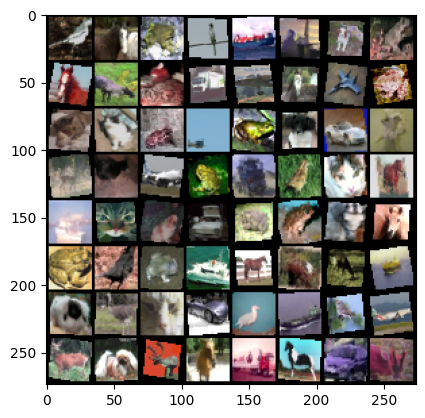

In [3]:
def random_grid(imgs, sz: int):
    samples_ix = torch.randint(low=0, high=len(imgs) - 1, size=(sz,))
    samples = imgs[samples_ix]
    grid = tu.make_grid(samples)
    return grid.permute(1, 2, 0)

augmented = torch.stack([x[0] for x in cifar_train])
tmps = random_grid(augmented, 64)
plt.imshow(tmps.cpu())
del augmented
del tmps

In [4]:
batchsize = 128

train_loader = tud.DataLoader(cifar_train, batch_size=batchsize, shuffle=True)
val_loader = tud.DataLoader(cifar_eval, batch_size=batchsize, shuffle=True)

In [5]:
class MyCnn(nn.Module):
    def __init__(self, out_sz=10, ch=32):
        super().__init__()

        self.channels = ch
        self.out_sz = out_sz
        # (32x32)
        self.conv1_1 = nn.Conv2d(3, ch, kernel_size=3, stride=1, padding=1)
        self.bn1_1 = nn.BatchNorm2d(ch)
        self.conv1_2 = nn.Conv2d(ch, ch*2, kernel_size=3, stride=1, padding=1)
        self.bn1_2 = nn.BatchNorm2d(ch*2)

        # (16x16)
        self.conv2_1 = nn.Conv2d(ch*2, ch*2, kernel_size=3, stride=1, padding=1)
        self.bn2_1 = nn.BatchNorm2d(ch*2)
        self.conv2_2 = nn.Conv2d(ch*2, ch*2, kernel_size=3, stride=1, padding=1)
        self.bn2_2 = nn.BatchNorm2d(ch*2)
        self.conv2_3 = nn.Conv2d(ch*2, ch*4, kernel_size=3, stride=1, padding=1)
        self.bn2_3 = nn.BatchNorm2d(ch*4)
        
        # (8x8)
        self.conv3_1 = nn.Conv2d(ch*4, ch*4, kernel_size=3, stride=1, padding=1)
        self.bn3_1 = nn.BatchNorm2d(ch*4)
        self.conv3_2 = nn.Conv2d(ch*4, ch*4, kernel_size=3, stride=1, padding=1)
        self.bn3_2 = nn.BatchNorm2d(ch*4)
        self.conv3_3 = nn.Conv2d(ch*4, ch*8, kernel_size=3, stride=1, padding=1)
        self.bn3_3 = nn.BatchNorm2d(ch*8)
        
        self.lin1 = nn.Linear((ch*8) * 4 * 4, 256, bias=True)
        self.lin2 = nn.Linear(256, 128, bias=True)
        self.lin3 = nn.Linear(128, out_sz, bias=True)

    def forward(self, x):
        x = self.conv1_1(x)
        x = F.relu(x)
        x = self.bn1_1(x)
        x = self.conv1_2(x)
        x = F.relu(x)
        x = self.bn1_2(x)
        x = F.max_pool2d(x, kernel_size=2)

        x = self.conv2_1(x)
        x = F.relu(x)
        x = self.bn2_1(x)
        x = self.conv2_2(x)
        x = F.relu(x)
        x = self.bn2_2(x)
        x = self.conv2_3(x)
        x = F.relu(x)
        x = self.bn2_3(x)
        x = F.max_pool2d(x, kernel_size=2)

        x = self.conv3_1(x)
        x = F.relu(x)
        x = self.bn3_1(x)
        x = self.conv3_2(x)
        x = F.relu(x)
        x = self.bn3_2(x)
        x = self.conv3_3(x)
        x = F.relu(x)
        x = self.bn3_3(x)
        x = F.max_pool2d(x, kernel_size=2)
        
        x = x.view(-1, (self.channels*8) * 4 * 4)
        x = self.lin1(x)
        x = F.relu(x)
        x = F.dropout(x, p=0.2)
        
        x = self.lin2(x)
        x = F.dropout(x, p=0.2)
        x = F.relu(x)
        
        x = self.lin3(x)
        x = F.softmax(x, dim=-1)
        return x
        

In [6]:
from torchinfo import summary
testmodel = MyCnn(out_sz=11, ch=64)
summary(testmodel, (1, 3, 32, 32))

Layer (type:depth-idx)                   Output Shape              Param #
MyCnn                                    [1, 11]                   --
├─Conv2d: 1-1                            [1, 64, 32, 32]           1,792
├─BatchNorm2d: 1-2                       [1, 64, 32, 32]           128
├─Conv2d: 1-3                            [1, 128, 32, 32]          73,856
├─BatchNorm2d: 1-4                       [1, 128, 32, 32]          256
├─Conv2d: 1-5                            [1, 128, 16, 16]          147,584
├─BatchNorm2d: 1-6                       [1, 128, 16, 16]          256
├─Conv2d: 1-7                            [1, 128, 16, 16]          147,584
├─BatchNorm2d: 1-8                       [1, 128, 16, 16]          256
├─Conv2d: 1-9                            [1, 256, 16, 16]          295,168
├─BatchNorm2d: 1-10                      [1, 256, 16, 16]          512
├─Conv2d: 1-11                           [1, 256, 8, 8]            590,080
├─BatchNorm2d: 1-12                      [1, 256, 8, 

Epoch 0: 2.0463271141052246 
Current LR is [0.01]
Epoch 1: 1.9580647945404053 
Epoch 2: 1.9096218347549438 
Epoch 3: 1.8846675157546997 
Epoch 4: 1.8730312585830688 
Epoch 5: 1.8529675006866455 
Epoch 6: 1.8523876667022705 
Epoch 7: 1.8390945196151733 
Epoch 8: 1.85154128074646 
Epoch 9: 1.8382545709609985 
Epoch 10: 1.8029025793075562 
Current LR is [0.005]
Epoch 11: 1.7891721725463867 
Epoch 12: 1.7893178462982178 
Epoch 13: 1.7810837030410767 
Epoch 14: 1.785427451133728 
Epoch 15: 1.7530994415283203 
Epoch 16: 1.7435065507888794 
Epoch 17: 1.7433334589004517 
Epoch 18: 1.7284975051879883 
Epoch 19: 1.7334136962890625 
Epoch 20: 1.7104544639587402 
Current LR is [0.0025]
Epoch 21: 1.7034929990768433 
Epoch 22: 1.7073246240615845 
Epoch 23: 1.6977485418319702 
Epoch 24: 1.7053606510162354 
Epoch 25: 1.7034461498260498 
Epoch 26: 1.6956775188446045 
Epoch 27: 1.6925591230392456 
Epoch 28: 1.6917120218276978 
Epoch 29: 1.6965924501419067 
Epoch 30: 1.6817231178283691 
Current LR is [0.

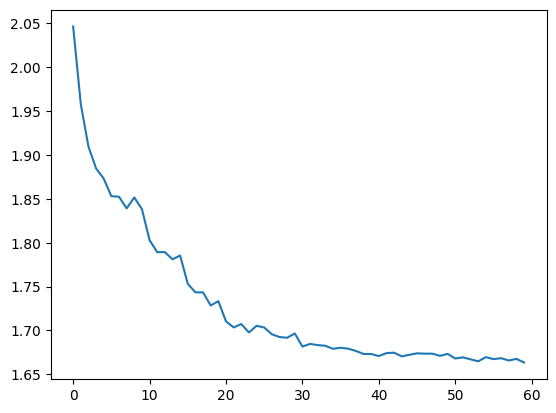

In [7]:
%%time

model = MyCnn(out_sz=11, ch=64).to(device).train()

optimizer = torch.optim.SGD(model.parameters(), lr=0.01, momentum=0.9)
# scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
#     optimizer,
#     'min',
#     patience=5,
#     verbose=True
# )
# cosine_scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
#     optimizer,
#     T_0=20,
#     verbose=False,
# )
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

lossfn = nn.CrossEntropyLoss()
epochs = 60

loss_plot = []
iters = len(train_loader)
try:
    for epoch in range(epochs):
        model.train()
        for i, (images, target) in enumerate(train_loader):
            optimizer.zero_grad()
            images = images.float().to(device)
            targets = target.float().to(device)
    
            outs = model(images)
            loss = lossfn(outs, targets.view(-1, 11))
            loss.backward()
            optimizer.step()
            # cosine_scheduler.step(epoch + i / iters)
    
        losses = []
        model.eval()
        for i, (images, target) in enumerate(val_loader):
            with torch.no_grad():
                images = images.float().to(device)
                targets = target.float().to(device)
                outs = model(images)
    
                loss = lossfn(outs, targets.view(-1, 11))
                losses.append(loss)
                    
        epoch_loss = torch.Tensor(losses).mean().item()
        print("Epoch {}: {} ".format(epoch, epoch_loss))
        if (epoch % 10) == 0:
            print("Current LR is {}".format(scheduler.get_last_lr()))
        loss_plot.append(epoch_loss)
        scheduler.step()
except KeyboardInterrupt:
    plt.plot(loss_plot)
plt.plot(loss_plot)

In [8]:
total = len(cifar_eval)
correct = 0
model.eval()
with torch.no_grad():
    for image, target in cifar_eval:
        pred = model(image.unsqueeze(0).float().to(device))
        if torch.allclose(pred.round().long().cpu(), target.cpu()):
            correct += 1
        
    print("{:.2f}% correct".format(100*correct/total))

87.78% correct
